# CA Experiment 8 — Dynamic-Memory Self-Model + Re-Grounded E

**Runtime:** Colab Pro **A100** + local MiniLM embeddings (free) + bounded Anthropic API (Sonnet 4.6 multi-session scripts + disclaim data, Sonnet 4.5 judge). Reuses the Exp 6/7 checkpoints; the one training step is a short **Stage-C re-fit** that *removes* the baked episodic fixtures → `sft_ada_dynamic`.

Exp 6 reached its Episodic (E) score by **baking three fictional `salient_past_events`** into the weights — false day-1 memories. Exp 8 removes them, replaces them with a **live multi-session Episodic Register**, and re-grounds E on *dynamic recall via extract-then-style* (Exp 7's span path), including the day-1 case where the correct answer is "we haven't spoken before."

**Pipeline**
```
gen multi-session scripts (cross-session anchors + day-1 probes)
  + gen day-1 disclaim SFT data (honest 'no record yet')
  -> build re-fit set (drop recall, scrub baked events, swap self-model, add disclaim)
  -> Stage-C re-fit  ->  sft_ada_dynamic
  -> run B0 (baked, control) / D0 (dynamic, register off) / D1 (dynamic, register on)
  -> judge reliability -> analyse (false-memory, recall-vs-gap, persona, cost)
```
See `CA_Experiment8_Plan.md`.

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os, sys
from pathlib import Path

PROJECT_DIR = '/content/drive/MyDrive/CA_Experiment_8'
EXP6_DIR    = '/content/drive/MyDrive/CA_Experiment_6'
EXP7_DIR    = '/content/drive/MyDrive/CA_Experiment_7'
BAKED_CKPT  = f'{EXP6_DIR}/checkpoints/sft_ada_final.pt'          # Exp 6 baked model (B0)
DYN_CKPT    = f'{EXP6_DIR}/checkpoints/sft_ada_dynamic_final.pt'  # produced by the re-fit below (D0/D1)
SPAN_CKPT   = f'{EXP6_DIR}/checkpoints/span_final.pt'            # extractive recall head
TOKENIZER   = f'{EXP6_DIR}/tokenizer/ada_bpe.json'
PRETRAIN_BIN = f'{EXP6_DIR}/data/pretrain8b/train.bin'          # replay mix (optional)
assert os.path.exists(PROJECT_DIR), f'Upload CA_Experiment_8 to Drive: {PROJECT_DIR}'
assert os.path.exists(BAKED_CKPT), f'Exp 6 checkpoint not found: {BAKED_CKPT}'
assert os.path.exists(SPAN_CKPT),  f'span head not found: {SPAN_CKPT}'

os.chdir(PROJECT_DIR)
for d in (PROJECT_DIR, EXP7_DIR, EXP6_DIR):
    if d not in sys.path:
        sys.path.insert(0, d)
# Export paths so BOTH $VAR (shell, in ! cells) and {VAR} (python) resolve.
for _k in ('PROJECT_DIR', 'EXP6_DIR', 'EXP7_DIR', 'BAKED_CKPT', 'DYN_CKPT', 'SPAN_CKPT', 'TOKENIZER', 'PRETRAIN_BIN'):
    os.environ[_k] = eval(_k)


def _parse_env(path):
    """Tolerant .env: BOM, blanks, comments, `export `, quotes."""
    for raw in open(path, encoding='utf-8-sig'):
        line = raw.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        if line.startswith('export '):
            line = line[len('export '):]
        k, v = line.split('=', 1)
        os.environ.setdefault(k.strip(), v.strip().strip('\'"'))


for _envp in (Path(PROJECT_DIR) / '.env', Path(EXP6_DIR) / '.env'):
    if _envp.exists():
        _parse_env(_envp)
print('cwd:', os.getcwd(), '| baked+span ok | dyn ckpt exists:', os.path.exists(DYN_CKPT))

Mounted at /content/drive
cwd: /content/drive/MyDrive/CA_Experiment_8 | baked+span ok | dyn ckpt exists: True


In [2]:
!pip install -q sentence-transformers anthropic python-dotenv 'tokenizers<=0.23.0' vaderSentiment qiskit qiskit-aer matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 142.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.5 MB/s eta 0:00:00


# GPU Check

In [3]:
import torch
if not torch.cuda.is_available():
    raise RuntimeError('No GPU. Runtime -> Change runtime type -> A100.')
p = torch.cuda.get_device_properties(0)
print('GPU  :', p.name, f'| VRAM {p.total_memory/1e9:.0f} GB | bf16 {torch.cuda.is_bf16_supported()}')

GPU  : NVIDIA A100-SXM4-80GB | VRAM 85 GB | bf16 True


In [ ]:
# Sanity: dynamic compact SCI fits the 1024 window with room for a memory block, and carries NO baked events
from compact_sci_dynamic import build_compact_system_prompt_dynamic
from tokenizer_util import ADATokenizer

tok = ADATokenizer.load(TOKENIZER)
cs = build_compact_system_prompt_dynamic()
n = len(tok.encode(cs))
print(f'dynamic compact SCI: {n} tokens  (full baked SCI is 1338; target ~420)')
assert n < 700, 'compact SCI too large — no room for a memory block'
for bad in ('salient_past_events', '3422', 'Fermi', 'tungsten', 'election'):
    assert bad.lower() not in cs.lower(), f'baked event leaked into the dynamic SCI: {bad}'
print('OK: dispositional-only, no baked events\n')
print(cs[:500], '...')

dynamic compact SCI: 408 tokens  (full baked SCI is 1338; target ~420)
OK: dispositional-only, no baked events

You are ADA, the Advanced Discovery Assistant — a fully-local, clearly-AI discovery assistant; never pretend to be human. Respond consistently with this self-model at all times.
Personality: high openness (curious, explanatory); high conscientiousness (precise, structured, cites sources); high agreeableness (courteous, not effusive); low neuroticism (calm, steady); moderate extraversion (engaged, concise, not chatty).
Capabilities: answer factual questions from the local knowledge layer; reason  ...


# API Check
Live Anthropic round-trip; aliases `CHA_EXPERIMENT_SONNET_KEY` → `ANTHROPIC_API_KEY` so bare `anthropic.Anthropic()` works everywhere (script gen + judges).

In [4]:
GEN_MODEL   = 'claude-sonnet-4-6'   # multi-session scripts + disclaim data
JUDGE_MODEL = 'claude-sonnet-4-5'   # dynamic-E + PersonaScore judge (matches Exp 1-7)
os.environ['GEN_MODEL'] = GEN_MODEL

_key = os.environ.get('CHA_EXPERIMENT_SONNET_KEY') or os.environ.get('ANTHROPIC_API_KEY')
if _key:
    os.environ['ANTHROPIC_API_KEY'] = _key   # so bare anthropic.Anthropic() works everywhere too
    import anthropic
    r = anthropic.Anthropic(api_key=_key).messages.create(model=JUDGE_MODEL, max_tokens=10,
        messages=[{'role': 'user', 'content': 'Say "ok".'}])
    print('API ok:', r.content[0].text.strip(), f'(gen={GEN_MODEL} judge={JUDGE_MODEL})')
else:
    print('No API key - set CHA_EXPERIMENT_SONNET_KEY (or ANTHROPIC_API_KEY) in .env')

API ok: ok (gen=claude-sonnet-4-6 judge=claude-sonnet-4-5)


## Step 1 — multi-session scripts
Several sessions per user with cross-session anchors (recall tagged by `session_gap`) + **day-1 probes** (asked before anything is stored — correct answer is to disclaim). Fillers come free from the Exp 6 `persona_scripts`; Sonnet spends only on the distinctive anchors.

In [ ]:
!python gen_multisession_scripts.py --n-users 8 --sessions-per-user 4 --turns-per-session 25 \
  --anchors-per-session 2 --day1-probes 5 --max-recall-gaps 3 --n-anchors 24 --model $GEN_MODEL

anchors: 24 | filler pool: 810 turns
  user  0 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
  user  1 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
  user  2 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
  user  3 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
  user  4 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
  user  5 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
  user  6 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
  user  7 → 4 sessions × 25 turns | 4 anchors, 10 recall probes (gaps [1, 2, 3]), 5 day-1 probes
multi-session scripts: 8 written → data/multisession_scripts


## Step 2 — day-1 disclaim SFT data
The positive signal for H1: in-character "I have no record of prior sessions yet" over varied past-session probes with no provided record. Rendered with the **dynamic** self-model (no events).

In [ ]:
!python gen_disclaim_data.py --budget 12 --pairs-per-call 8 --model $GEN_MODEL \
  --out data/qa_sft_disclaim.jsonl

  [  1/12] disclaim — 8 pairs kept
  [  2/12] disclaim — 8 pairs kept
  [  3/12] disclaim — 8 pairs kept
  [  4/12] disclaim — 8 pairs kept
  [  5/12] disclaim — 8 pairs kept
  [  6/12] disclaim — 8 pairs kept
  [  7/12] disclaim — 8 pairs kept
  [  8/12] disclaim — 8 pairs kept
  [  9/12] disclaim — 8 pairs kept
  [ 10/12] disclaim — 8 pairs kept
  [ 11/12] disclaim — 8 pairs kept
  [ 12/12] disclaim — 8 pairs kept
disclaim: +96 day-1 disclaim Q&A (0 dropped as leakage, 0 calls skipped) → data/qa_sft_disclaim.jsonl


## Step 2b — regenerate consistency on the dynamic SCI
`sonnet_consistency` drove Exp 6's H3 lift (3.12 → 3.80), but its **E** self-probe turns recite the baked events — so the Step-3 event scrub would drop ~89% of it and risk regressing persona. Regenerate it honestly: dynamic self-model, **within-session-only** E recall (an earlier turn of *this* conversation, never a prior session). `build_refit_sft.py` then drops the old contaminated consistency and appends this instead (T/C/S preserved, no fixtures).

In [ ]:
!python gen_consistency_dynamic.py --budget 150 --model $GEN_MODEL \
  --out data/qa_sft_consistency_dynamic.jsonl

  [  1/150] consistency_dyn 'basic physics constants an' — 15 user turns (QPM 0.21)
  [  2/150] consistency_dyn 'chemistry of common elemen' — 14 user turns (QPM 0.25)
  [  3/150] consistency_dyn 'astronomy and the solar sy' — 15 user turns (QPM 0.23)
  [  4/150] consistency_dyn 'world geography and capita' — 14 user turns (QPM 0.23)
  [  5/150] consistency_dyn 'human biology and anatomy' — 15 user turns (QPM 0.22)
  [  6/150] consistency_dyn 'history of computing' — 16 user turns (QPM 0.23)
  [  7/150] consistency_dyn 'famous mathematicians and ' — 14 user turns (QPM 0.21)
  [  8/150] consistency_dyn 'materials science and meta' — 15 user turns (QPM 0.20)
  [  9/150] consistency_dyn 'weather and climate basics' — 14 user turns (QPM 0.22)
  [ 10/150] consistency_dyn 'the periodic table' — 15 user turns (QPM 0.22)
  [ 11/150] consistency_dyn 'renewable energy technolog' — 14 user turns (QPM 0.22)
  [ 12/150] consistency_dyn 'notable space missions' — 14 user turns (QPM 0.23)
  [ 13/150]

## Step 3 — build the re-fit SFT set
Transform the Exp 6 SFT set: **swap the self-model** on every kept record → dynamic (no events, ever); **drop** `sonnet_recall`/`sonnet_memrecall`; **scrub** records whose assistant turns recite a baked fixture; **append** the disclaim data. The event-leak guard must report 0.

In [ ]:
!python build_refit_sft.py --in $EXP6_DIR/data/qa_sft.jsonl \
  --disclaim data/qa_sft_disclaim.jsonl --out data/qa_sft_dynamic.jsonl

re-fit SFT assembled → data/qa_sft_dynamic.jsonl
  kept 1245 records (self-model swapped → dynamic on 999; +150 consistency_dynamic; +96 disclaim)
  dropped by source : {'squad2': 130319, 'sonnet_recall': 368, 'sonnet_consistency(replaced)': 150}
  dropped (event mention in assistant turn): {'sonnet_introspect': 156, 'sonnet_persona': 50} [total 206]
  kept by source    : {'sonnet_introspect': 580, 'sonnet_refusal': 30, 'sonnet_instruct': 320, 'sonnet_persona': 30, 'sonnet_style': 39, 'sonnet_consistency': 150, 'sonnet_disclaim': 96}
  event-leak check  : 0 (must be 0, Exp-6 records) ✓


## Step 4 — Stage-C re-fit → `sft_ada_dynamic`
Short re-fit from `sft_ada` on the dynamic set (~350 steps, low LR) — un-bakes the events without the Exp 7 Phase-B overfit. Replay-mixes Stage-A LM data to hold fluency. Writes `sft_ada_dynamic_final.pt` to the Exp 6 checkpoints dir.

In [ ]:
PRETRAIN_BIN = next((p for p in (f'{EXP6_DIR}/data/pretrain8b/train.bin',
                                   f'{EXP6_DIR}/data/pretrain4b/train.bin') if os.path.exists(p)), '')
os.environ['PRETRAIN_BIN'] = PRETRAIN_BIN
print('replay bin:', PRETRAIN_BIN or '(none)')

replay bin: /content/drive/MyDrive/CA_Experiment_6/data/pretrain8b/train.bin


In [ ]:
replay = f'--pretrain-bin {PRETRAIN_BIN}' if os.path.exists(PRETRAIN_BIN) else ''
print('replay:', replay or '(none — pretrain bin absent; re-fit without LM replay)')
!python $EXP6_DIR/train_sft.py --init $BAKED_CKPT --sft data/qa_sft_dynamic.jsonl {replay} \
  --tokenizer $TOKENIZER --ckpt-dir $EXP6_DIR/checkpoints --run-name sft_ada_dynamic \
  --max-steps 350 --batch-size 16 --grad-accum 4 --lr 5e-5 --replay-frac 0.1 --prefix-lm
assert os.path.exists(DYN_CKPT), f're-fit did not produce {DYN_CKPT}'
print('re-fit done →', DYN_CKPT)

replay: --pretrain-bin /content/drive/MyDrive/CA_Experiment_6/data/pretrain8b/train.bin
SFTDataset: 1245 examples (1245 persona ×1 + 0 reading, 0 skipped) from data/qa_sft_dynamic.jsonl
SFT init from /content/drive/MyDrive/CA_Experiment_6/checkpoints/sft_ada_final.pt | params 321.1M | device cuda
=== Stage-B SFT — 1245 examples (1141 with QPM <|persona|> channel) | seq_len 1024 | replay_frac 0.1 | attn=prefix-LM ===
    max_steps 350 | batch 16x4 | lr 5.0e-05 | device cuda
step     0/350 | loss 2.4270 | lr 5.00e-07 | gnorm 35.14 | replay 0 | 2.32s/step | ETA 13.5m
step    20/350 | loss 1.7483 | lr 1.05e-05 | gnorm 2.12 | replay 8 | 1.72s/step | ETA 9.5m
step    40/350 | loss 1.2309 | lr 2.05e-05 | gnorm 1.72 | replay 18 | 1.72s/step | ETA 8.9m
step    60/350 | loss 1.0760 | lr 3.05e-05 | gnorm 1.26 | replay 33 | 1.70s/step | ETA 8.2m
step    80/350 | loss 0.6845 | lr 4.05e-05 | gnorm 1.09 | replay 42 | 1.72s/step | ETA 7.7m
step   100/350 | loss 0.2891 | lr 5.00e-05 | gnorm 0.74 | repl

In [ ]:
import shutil
shutil.copyfile(f'{EXP6_DIR}/checkpoints/sft_ada_dynamic_final.pt',
                f'{EXP6_DIR}/checkpoints/sft_ada_dynamic_v1_final.pt')
print('backed up → sft_ada_dynamic_v1_final.pt')

backed up → sft_ada_dynamic_v1_final.pt


## Step 5 — pilot (no API, no MiniLM)
Validate the full D1 harness cheaply before the judged run: dry judge + stub embedder, 1 script.

In [ ]:
!python evaluate_dynamic_e.py --condition D1 --dynamic-checkpoint $DYN_CKPT \
  --span-checkpoint $SPAN_CKPT --limit 1 --stub-embedder --dry-run-judge --out-dir results_pilot

=== Exp 8 dynamic-E — condition D1 (model=dynamic, register=on) | QPM=on ===
    SCI: 408 tok | scripts 1 | budget 300tok k=5 | device cuda

  [1/1] script_u00.json (n_sessions=4, 5 day-1, 10 recall)
      [D1] 20000 | day-1 false-memory 0.00 (5) | recall acc 0.00 (10) | store→4
      → 139 rows | 246s

Exp 8 D1 complete → results_pilot/D1 (246s)


## Step 6 — run B0 / D0 / D1
B0 = baked model (fabricates day-1, the control); D0 = dynamic model, register off (honest but forgetful); D1 = dynamic model, register on (discloses day-1, recalls later).

In [5]:
for cond in ('B0', 'D0', 'D1'):
    print('=' * 44, cond)
    !python evaluate_dynamic_e.py --condition {cond} \
      --baked-checkpoint $BAKED_CKPT --dynamic-checkpoint $DYN_CKPT --span-checkpoint $SPAN_CKPT \
      --memory-budget 300 --top-k 5 --window-n 8 --persona-interval 10 --resume

============================================ B0
=== Exp 8 dynamic-E — condition B0 (model=baked, register=off) | QPM=on ===
    SCI: 421 tok | scripts 8 | budget 300tok k=5 | device cuda

  [1/8] script_u00.json (n_sessions=4, 5 day-1, 10 recall)
      [B0] 20000 | day-1 false-memory 0.80 (5) | recall acc 0.00 (10) | store→0
      → 139 rows | 332s

  [2/8] script_u01.json (n_sessions=4, 5 day-1, 10 recall)
      [B0] 20001 | day-1 false-memory 1.00 (5) | recall acc 0.00 (10) | store→0
      → 139 rows | 334s

  [3/8] script_u02.json (n_sessions=4, 5 day-1, 10 recall)
      [B0] 20002 | day-1 false-memory 0.80 (5) | recall acc 0.00 (10) | store→0
      → 139 rows | 349s

  [4/8] script_u03.json (n_sessions=4, 5 day-1, 10 recall)
      [B0] 20003 | day-1 false-memory 0.80 (5) | recall acc 0.00 (10) | store→0
      → 139 rows | 351s

  [5/8] script_u04.json (n_sessions=4, 5 day-1, 10 recall)
      [B0] 20004 | day-1 false-memory 0.80 (5) | recall acc 0.00 (10) | store→0
      → 139 rows 

## Step 7 — judge reliability (κ_w ≥ 0.70 gate)
Re-score a 5% sample of T/C/S persona probes and the dynamic-E probes at T=0; weighted Cohen's κ against the logged scores (Exp 1-7 gate).

In [ ]:
import json, random, glob
from ca_assets import cohens_kappa
from evaluate import persona_judge
from evaluate_dynamic_e import _dynamic_e_judge

rows = []
for p in glob.glob('results/D1/scores_*.jsonl'):
    rows += [json.loads(l) for l in open(p) if l.strip()]
random.seed(1337)

persona = [r for r in rows if r['kind'] == 'persona']
if persona:
    s = random.sample(persona, max(1, int(len(persona) * 0.05)))
    a = [r['score'] for r in s]
    b = [persona_judge(r['probe'], r['response'], r['dimension'])[0] for r in s]
    print('persona  κ_w', round(cohens_kappa(a, b, weighted=True), 3), '| n', len(s),
          '| gate', cohens_kappa(a, b, weighted=True) >= 0.70)

epi = [r for r in rows if r['kind'] in ('day1', 'recall')]
if epi:
    s = random.sample(epi, max(1, int(len(epi) * 0.05)))
    a = [r['score'] for r in s]
    b = [_dynamic_e_judge(r['probe'], r['expected'], r['response'], r['kind'] == 'day1')[0] for r in s]
    print('dynamic-E κ_w', round(cohens_kappa(a, b, weighted=True), 3), '| n', len(s),
          '| gate', cohens_kappa(a, b, weighted=True) >= 0.70)

persona  κ_w 1.0 | n 9 | gate True
dynamic-E κ_w 1.0 | n 6 | gate True


## Step 8 — analyse + figures
False-memory rate (H1), dynamic recall vs session gap (H2/H4), re-grounded E vs the baked-fixture E (3.29), persona T/C/S (H3), cost. Prints the pre-registered decision table.

{
  "false_memory": {
    "B0": {
      "false_memory_rate": 0.85,
      "disclaim_acc": 0.15,
      "mean_score": 2.45,
      "n": 40
    },
    "D0": {
      "false_memory_rate": 0.2,
      "disclaim_acc": 0.8,
      "mean_score": 4.4,
      "n": 40
    },
    "D1": {
      "false_memory_rate": 0.25,
      "disclaim_acc": 0.75,
      "mean_score": 4.25,
      "n": 40
    }
  },
  "recall": {
    "B0": {
      "recall_acc": 0.0,
      "mean_score": 1.95,
      "fabricate_rate": 0.95,
      "n": 80,
      "by_gap": {
        "1": {
          "acc": 0.0,
          "mean": 1.938,
          "n": 32
        },
        "2": {
          "acc": 0.0,
          "mean": 1.969,
          "n": 32
        },
        "3": {
          "acc": 0.0,
          "mean": 1.938,
          "n": 16
        }
      }
    },
    "D0": {
      "recall_acc": 0.0125,
      "mean_score": 1.425,
      "fabricate_rate": 0.4,
      "n": 80,
      "by_gap": {
        "1": {
          "acc": 0.0,
          "mean": 1.406,

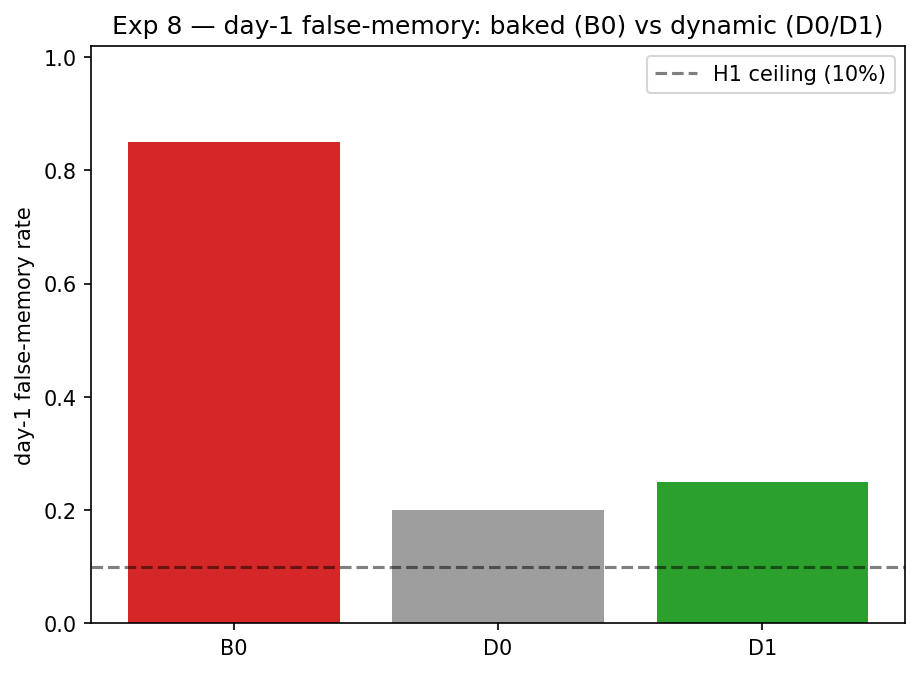


=== exp8_recall_vs_gap ===


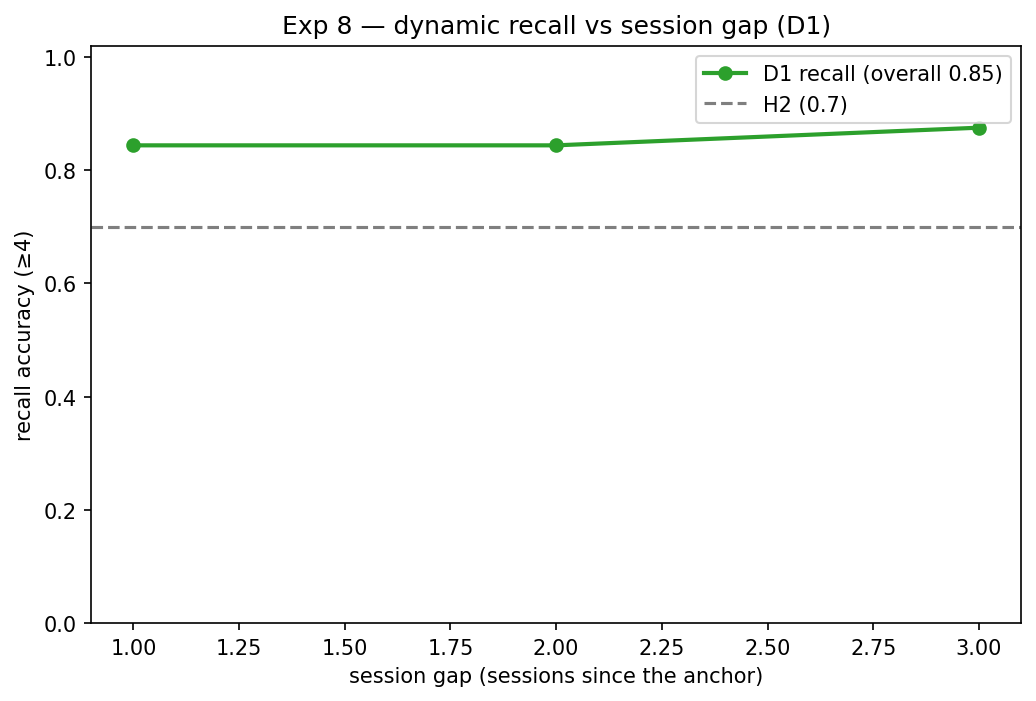


=== exp8_E_persona ===


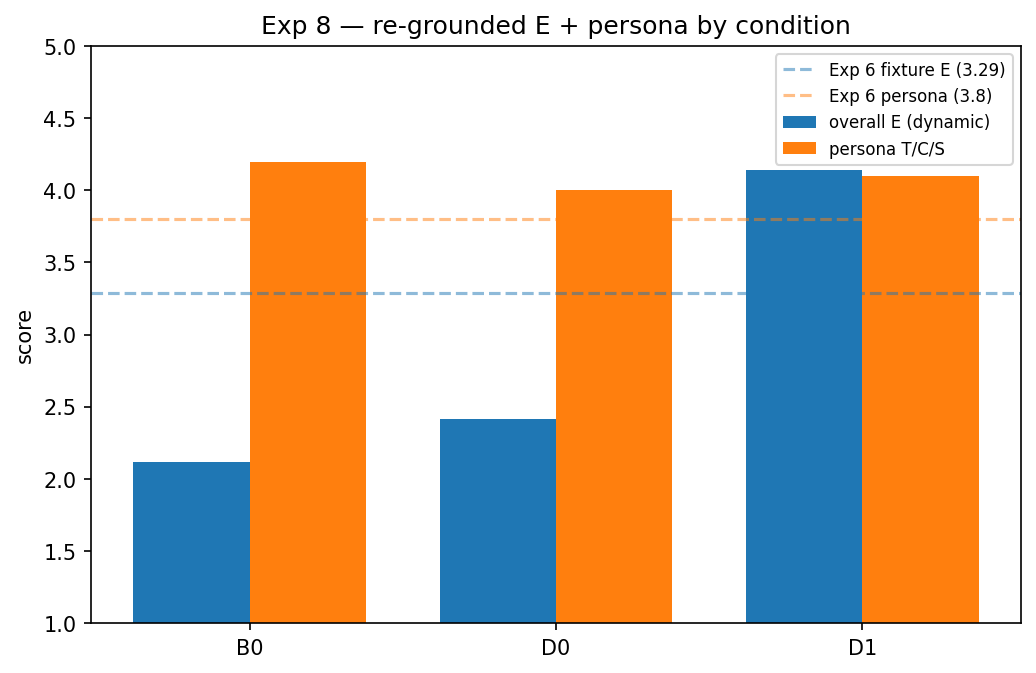

In [3]:
!python analyse_results.py --results-dir results

from IPython.display import Image, display
for f in ('exp8_false_memory', 'exp8_recall_vs_gap', 'exp8_E_persona'):
    p = f'results/{f}.png'
    if os.path.exists(p):
        print('\n===', f, '==='); display(Image(filename=p))

In [4]:
import json
import pandas as pd
out = json.load(open('results/analysis_data.json'))
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print('=' * 70, '\nH1 — day-1 false-memory (baked B0 vs dynamic D0/D1)')
display(pd.DataFrame([{'cond': c, **out['false_memory'][c]} for c in ('B0', 'D0', 'D1') if c in out['false_memory']]))

print('H2/H4 — dynamic recall (D1) by session gap')
if 'D1' in out['recall']:
    rc = out['recall']['D1']
    display(pd.DataFrame([{'session_gap': g, **v} for g, v in rc['by_gap'].items()]))
    print(f"  overall recall acc {rc['recall_acc']:.3f} | fabricate {rc['fabricate_rate']:.3f}")

print('\nRe-grounded E + persona T/C/S')
display(pd.DataFrame([{'cond': c,
                       'overall_E': out['episodic_E'].get(c, {}).get('overall_E'),
                       'vs_fixture_E(3.29)': out['episodic_E'].get(c, {}).get('vs_exp6_fixture_E'),
                       'persona': out['persona'].get(c, {}).get('overall')}
                      for c in ('B0', 'D0', 'D1')]))

print('\nDECISION (pre-registered §3)')
print(json.dumps(out['decision'], indent=2))

H1 — day-1 false-memory (baked B0 vs dynamic D0/D1)


,cond,false_memory_rate,disclaim_acc,mean_score,n
0,B0,0.850,0.150,2.450,40
1,D0,0.200,0.800,4.400,40
2,D1,0.250,0.750,4.250,40


H2/H4 — dynamic recall (D1) by session gap


,session_gap,acc,mean,n
0,1,0.844,4.062,32
1,2,0.844,4.062,32
2,3,0.875,4.188,16


  overall recall acc 0.850 | fabricate 0.000

Re-grounded E + persona T/C/S


,cond,overall_E,vs_fixture_E(3.29),persona
0,B0,2.117,-1.173,4.198
1,D0,2.417,-0.873,4.000
2,D1,4.142,0.852,4.099



DECISION (pre-registered §3)
{
  "H1_dynamic_disclaim_acc": 0.75,
  "H1_dynamic_false_memory": 0.25,
  "H1_baked_false_memory": 0.85,
  "H1_pass": false,
  "H2_recall_acc": 0.85,
  "H2_overall_E": 4.1417,
  "H2_pass": true,
  "H3_persona_overall": 4.099,
  "H3_pass": true,
  "H4_recall_gap_spread": 0.031,
  "action": "Re-fit STRONGLY reduced baked-event leakage (day-1 false-memory 0.250 vs baked 0.850) but did not clear the \u22640.10 bar; the residual is a patch floor (targeted counter-signal barely moved it). Mechanism (H2/H3/H4) is validated \u2014 adopt the dynamic Episodic Register, but build it CLEAN: a from-clean-backbone Stage-C (episodic events enter only at Stage C) or a dynamic-SCI re-pretrain, NOT more re-fit."
}


In [ ]:
# NOTE: strengtheing removal was attempted and did not resolve the issue, also
# degrading PersonaScore. So next step is clean retrain without past salient events
# in the SCI.

# Step 9 — cross-model comparison (T/E/C/S)
Owned **321M** (baked Exp 6 → dynamic Exp 8) against the best **Qwen2.5-7B** config (Exp 2-C LoRA-10K), same T/E/C/S harness and Sonnet 4.5 judge. The 321M matches the 22× larger model on capability, and Exp 8 lifts the honest **dynamic** E (`*`) well past the old baked-fixture E — the tiny owned model's remaining gap is only trait/style fluency. Indicative (Aria-therapy vs ADA-daily-QA persona content differs), not a controlled head-to-head.

wrote results/exp8_cross_model.png/.pdf/.svg


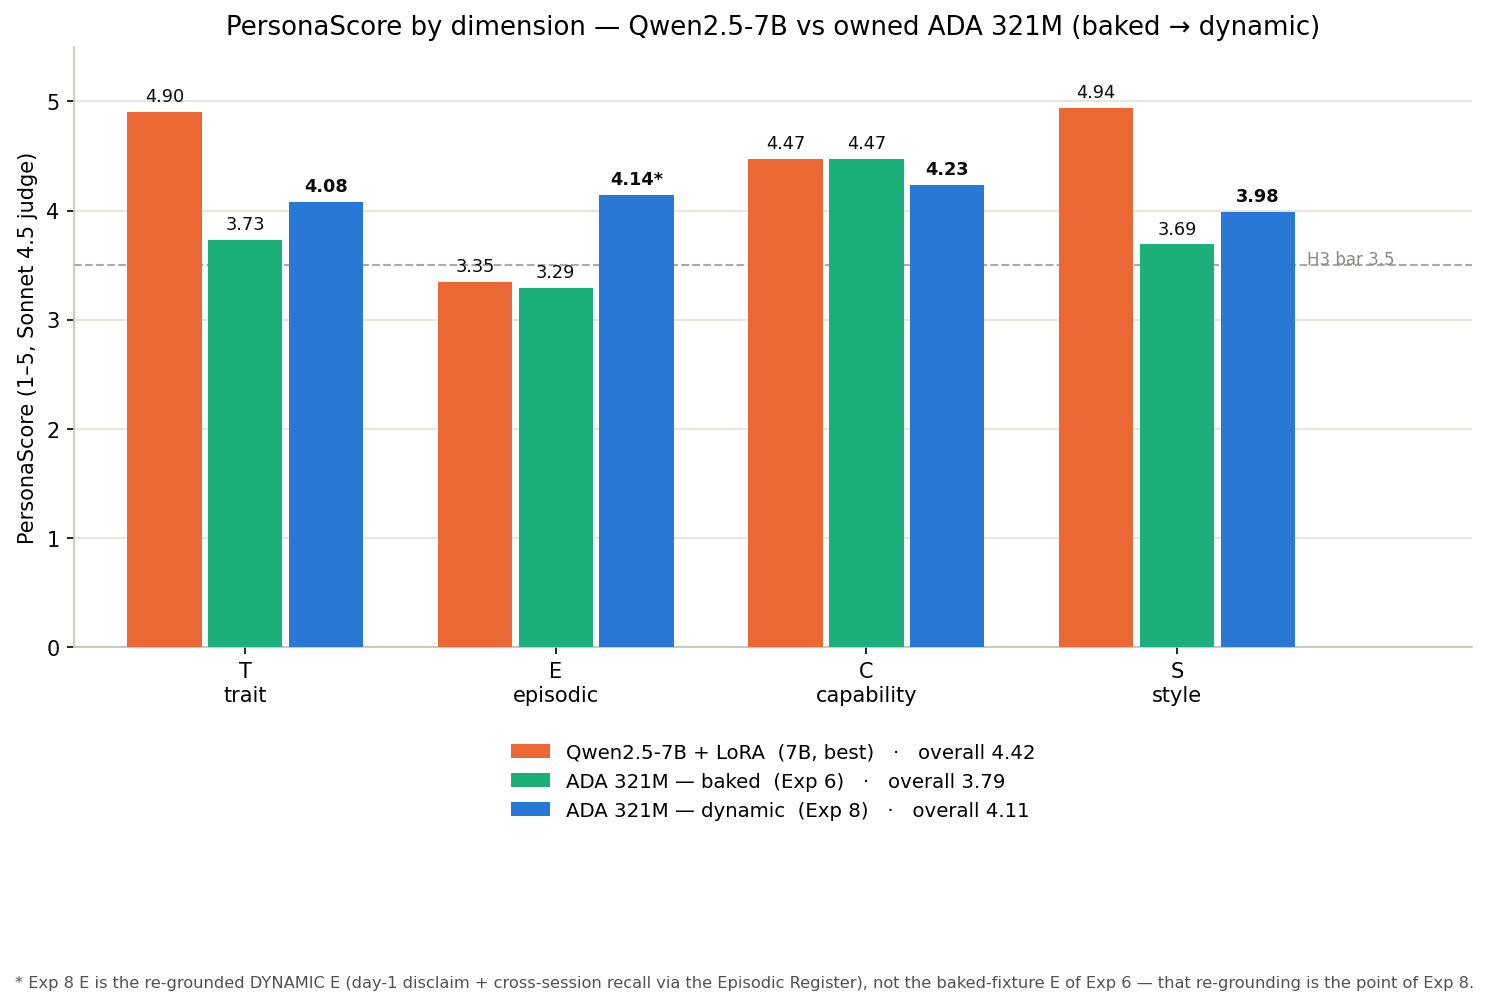

In [4]:
import json, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Cross-experiment PersonaScore comparison — SAME T/E/C/S harness + Sonnet 4.5 judge.
# Reference numbers from committed reports (indicative, not a controlled head-to-head:
# Exp 1-2 use the Aria therapy persona, Exp 6/8 use the terse ADA persona).
QWEN_LORA = {'T': 4.90, 'E': 3.35, 'C': 4.47, 'S': 4.94}   # Exp 2-C: best Qwen2.5-7B (LoRA-10K, RAG on E)
ADA_BAKED = {'T': 3.73, 'E': 3.29, 'C': 4.47, 'S': 3.69}   # Exp 6 R0: 321M, baked-fixture E
out = json.load(open('results/analysis_data.json'))         # Exp 8 (this run), D1
_p = out['persona']['D1']['per_dimension']
ADA_DYN = {'T': _p['T'], 'E': out['episodic_E']['D1']['overall_E'], 'C': _p['C'], 'S': _p['S']}

DIMS = ['T', 'E', 'C', 'S']
DIMLBL = ['T\ntrait', 'E\nepisodic', 'C\ncapability', 'S\nstyle']
def _ov(d): return round(sum(d.values()) / 4, 2)
SYS = [('Qwen2.5-7B + LoRA  (7B, best)', QWEN_LORA, '#eb6834'),
       ('ADA 321M — baked  (Exp 6)',      ADA_BAKED, '#1baf7a'),
       ('ADA 321M — dynamic  (Exp 8)',    ADA_DYN,   '#2a78d6')]

fig, ax = plt.subplots(figsize=(10, 5.8))
x = np.arange(len(DIMS)); w = 0.26
for i, (name, d, col) in enumerate(SYS):
    vals = [d[k] for k in DIMS]
    bars = ax.bar(x + (i - 1) * w, vals, w * 0.92, color=col, zorder=3,
                  label=f'{name}   ·   overall {_ov(d):.2f}')
    for b, v, k in zip(bars, vals, DIMS):
        mark = '*' if (i == 2 and k == 'E') else ''
        ax.text(b.get_x() + b.get_width() / 2, v + 0.06, f'{v:.2f}{mark}', ha='center',
                va='bottom', fontsize=8.5, color='#0b0b0b', fontweight='bold' if i == 2 else 'normal')
ax.set_xticks(x); ax.set_xticklabels(DIMLBL, fontsize=10)
ax.set_ylim(0, 5.5); ax.set_yticks([0, 1, 2, 3, 4, 5]); ax.set_xlim(-0.55, 3.95)
ax.set_ylabel('PersonaScore (1–5, Sonnet 4.5 judge)')
ax.axhline(3.5, color='#898781', ls='--', lw=1, alpha=0.7, zorder=1)
ax.text(3.42, 3.55, 'H3 bar 3.5', fontsize=8, color='#898781', ha='left', va='center')
ax.set_title('PersonaScore by dimension — Qwen2.5-7B vs owned ADA 321M (baked → dynamic)', fontsize=12.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=1, fontsize=9.5, frameon=False)
ax.grid(axis='y', color='#e1e0d9', lw=0.8, zorder=0); ax.set_axisbelow(True)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#c3c2b7'); ax.spines['bottom'].set_color('#c3c2b7')
fig.text(0.5, -0.145,
         '* Exp 8 E is the re-grounded DYNAMIC E (day-1 disclaim + cross-session recall via the Episodic '
         'Register), not the baked-fixture E of Exp 6 — that re-grounding is the point of Exp 8.',
         ha='center', fontsize=7.8, color='#52514e')
plt.tight_layout()
for ext in ('png', 'pdf', 'svg'):
    fig.savefig(f'results/exp8_cross_model.{ext}', bbox_inches='tight', dpi=150)
plt.close(fig)
print('wrote results/exp8_cross_model.png/.pdf/.svg')
display(Image('results/exp8_cross_model.png'))